In [1]:
import pandas as pd
import seaborn as  sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import os

In [4]:
df = pd.read_csv('EMMA_complete.csv',
                 delimiter=',',
                 encoding='ANSI',
                 na_values='NA').dropna()

classic = pd.read_csv('EMMA_classic.csv',
                 delimiter=',',
                 encoding='ANSI',
                 na_values='NA').dropna()

electronic = pd.read_csv('EMMA_electronic.csv',
                 delimiter=',',
                 encoding='ANSI',
                 na_values='NA').dropna()

funk_soul = pd.read_csv('EMMA_funk_soul.csv',
                 delimiter=',',
                 encoding='ANSI',
                 na_values='NA').dropna()

hip_hop = pd.read_csv('EMMA_hip_hop.csv',
                 delimiter=',',
                 encoding='ANSI',
                 na_values='NA').dropna()

jazz = pd.read_csv('EMMA_jazz.csv',
                 delimiter=',',
                 encoding='ANSI',
                 na_values='NA').dropna()

pop = pd.read_csv('EMMA_pop.csv',
                 delimiter=',',
                 encoding='ANSI',
                 na_values='NA').dropna()

rock = pd.read_csv('EMMA_rock.csv',
                 delimiter=',',
                 encoding='ANSI',
                 na_values='NA').dropna()


df["genre"] = df["Spotify ID"].map(
    lambda x: "classic" if x in classic.values
              else "electronic" if x in electronic.values
              else "funk_soul" if x in funk_soul.values
              else "hip_hop" if x in hip_hop.values
              else "jazz" if x in jazz.values
              else "pop" if x in pop.values
              else "rock" if x in rock.values
              else ""
    )

df.to_csv('emma_spotify.csv')

df.head()

,Unnamed: 0,artist,title,Wonder,Transcendence,Nostalgia,Tenderness,Peacefulness,Joy,Power,Tension,Sadness,Spotify ID,genre
0,1,The Thrillseekers,Synaesthesia (Fly Away) - Radio Edit,15.75,16.12,16.12,8.25,5.88,41.62,40.69,20.69,2.75,5QdgpcfAw8EbsupH0B6BpI,electronic
1,2,Jorge Ben,Ponta de lança africano (Umbabarauma),23.00,15.96,7.57,2.30,13.22,46.30,32.09,14.35,1.22,0jayFuH5lbwOOVeJnwDgGf,jazz
2,3,Lamb,Heaven,12.60,17.50,22.75,14.80,15.65,13.35,26.00,15.05,11.30,0bjTW3zBohWdYy2z1Sf5hJ,electronic
3,4,Milton Nascimento,Cais,13.41,7.82,13.47,19.94,25.59,1.82,5.18,8.35,16.88,1PVLHOm7WUbZMChq8JAFW9,jazz
4,5,Kylie Minogue,Please Stay (7th District Radio Mix),13.92,12.50,10.29,6.92,8.08,36.67,31.12,16.04,1.58,5MqHbBqicUU0wyXwk7TJR7,pop


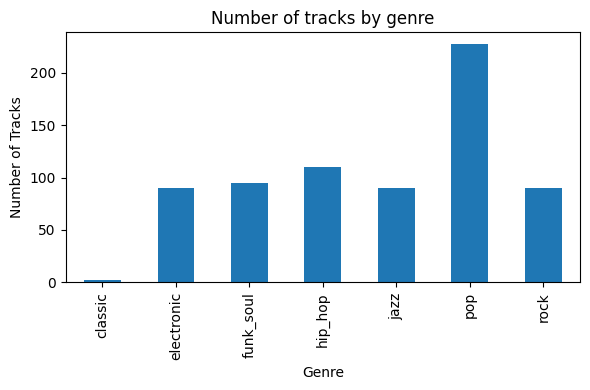

In [35]:
counts = df["genre"].value_counts().sort_index()


plt.figure(figsize=(6,4))
counts.plot(kind="bar")
plt.title("Number of tracks by genre")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.tight_layout()
plt.show()

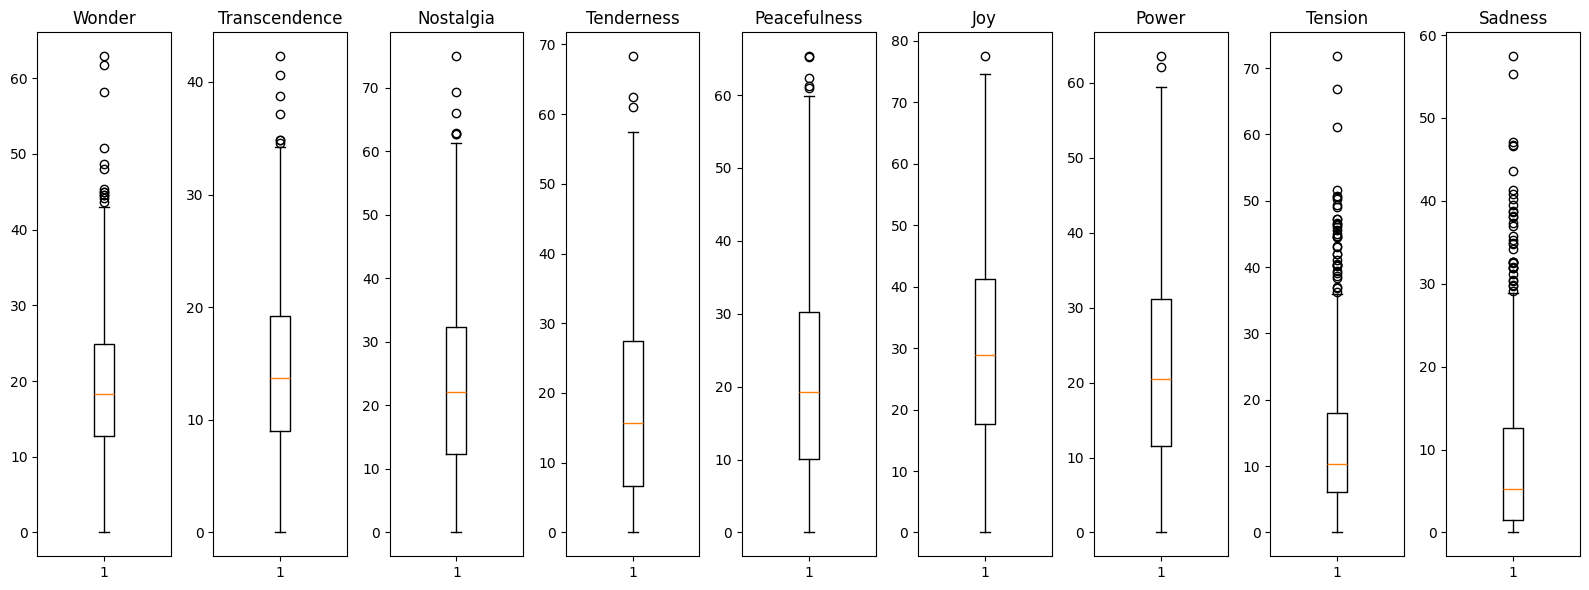

In [44]:
emotions_col = ['Wonder', 'Transcendence', 'Nostalgia',
                'Tenderness', 'Peacefulness', 'Joy',
                'Power','Tension','Sadness']

fig, axs = plt.subplots(1, 9, figsize=(16, 6))

for i, emo in enumerate(emotions_col):

    axs[i].boxplot(df[emo])
    axs[i].set_title(f"{emo}")
    # axs[i].set_ylabel(emo)

plt.tight_layout()
plt.show()

In [45]:
df_emo = df[emotions_col]
correlation_matrix = df_emo.corr()

correlation_matrix

,Wonder,Transcendence,Nostalgia,Tenderness,Peacefulness,Joy,Power,Tension,Sadness
Wonder,1.000000,0.494540,0.514128,0.470487,0.436335,0.239657,0.069676,-0.416040,0.231278
Transcendence,0.494540,1.000000,0.383944,0.330850,0.264882,-0.022681,0.224726,-0.068713,0.352060
Nostalgia,0.514128,0.383944,1.000000,0.642523,0.526057,0.084767,-0.065483,-0.509968,0.398689
Tenderness,0.470487,0.330850,0.642523,1.000000,0.751474,-0.210350,-0.352512,-0.544553,0.489799
Peacefulness,0.436335,0.264882,0.526057,0.751474,1.000000,-0.259614,-0.519106,-0.546367,0.389638
Joy,0.239657,-0.022681,0.084767,-0.210350,-0.259614,1.000000,0.582013,-0.158473,-0.519891
Power,0.069676,0.224726,-0.065483,-0.352512,-0.519106,0.582013,1.000000,0.306361,-0.257919
Tension,-0.416040,-0.068713,-0.509968,-0.544553,-0.546367,-0.158473,0.306361,1.000000,-0.136259
Sadness,0.231278,0.352060,0.398689,0.489799,0.389638,-0.519891,-0.257919,-0.136259,1.000000


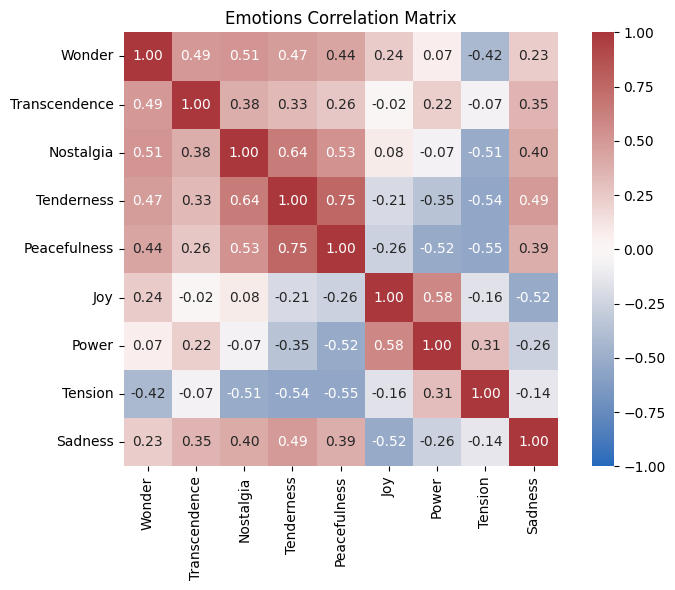

In [46]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, 
            annot=True,
            cmap='vlag',
            fmt='.2f',
            vmin= -1,
            vmax=1,
            square=True)
plt.title('Emotions Correlation Matrix')
plt.tight_layout()
plt.show()

In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_emo)

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

print(f'Variance expliquée : {pca.explained_variance_ratio_}')

Variance expliquée : [0.41752704 0.21882344 0.1430388  0.06166297]


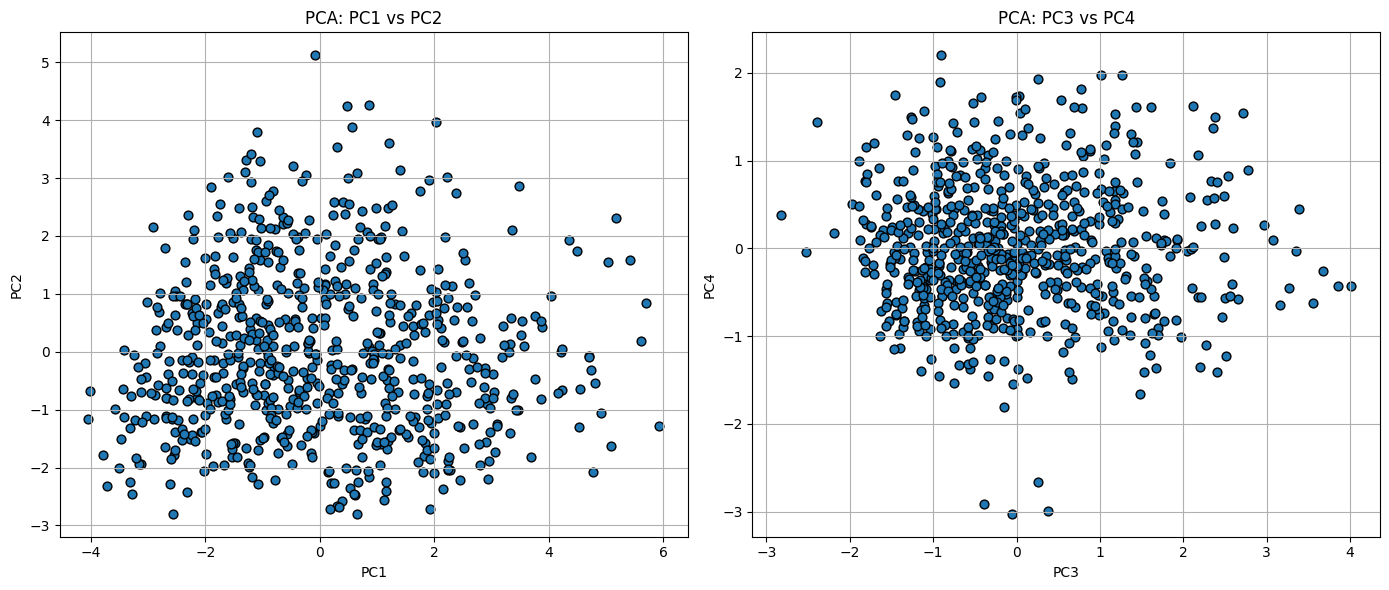

In [50]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

axs[0].scatter(X_pca[:, 0], X_pca[:, 1], edgecolor='k', s=40)
axs[0].set_xlabel('PC1')
axs[0].set_ylabel('PC2')
axs[0].set_title('PCA: PC1 vs PC2')
axs[0].grid(True)

axs[1].scatter(X_pca[:, 2], X_pca[:, 3], edgecolor='k', s=40)
axs[1].set_xlabel('PC3')
axs[1].set_ylabel('PC4')
axs[1].set_title('PCA: PC3 vs PC4')
axs[1].grid(True)

plt.tight_layout()
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


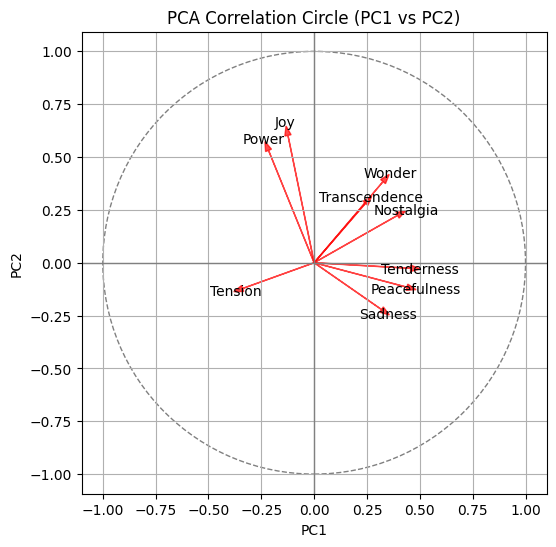

In [33]:
loadings = pca.components_.T

plt.figure(figsize=(6, 6))
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)

for i in range(len(emotions_col)):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1],
              color='red', alpha=0.7, head_width=0.03)
    plt.text(loadings[i, 0]*1.1, loadings[i, 1]*1.1,
             emotions_col[i], color='k', ha='center', va='center')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Correlation Circle (PC1 vs PC2)')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='datalim')
plt.grid(True)
plt.show()

c:\Users\paulz\Desktop\MJF GEMS ANNOTATION\venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


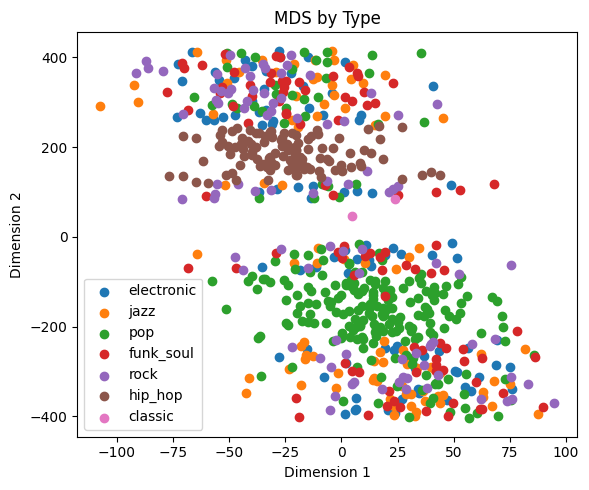

In [53]:
X = df.select_dtypes(include="number")
labels = df["genre"]

mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X)

plt.figure(figsize=(6,5))
for t in labels.unique():
    idx = labels == t
    plt.scatter(X_mds[idx, 0], X_mds[idx, 1], label=t)

plt.legend()
plt.title("MDS by Type")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.tight_layout()
plt.show()

# Prerpocess Data

In [5]:
df = df[['artist', 'title','Wonder', 'Transcendence', 'Nostalgia',
         'Tenderness', 'Peacefulness', 'Joy', 'Power','Tension',
         'Sadness', 'Spotify ID']]

df['path'] = pd.NA

for track in os.listdir('tracks/'):

    df.loc[df['Spotify ID'] == track[:-4], 'path'] = f'tracks/{track}'

df = df[~(df['path'].isna())]
df.drop_duplicates(subset='path')
df.to_csv('emma_final.csv')
df

,artist,title,Wonder,Transcendence,Nostalgia,Tenderness,Peacefulness,Joy,Power,Tension,Sadness,Spotify ID,path
0,The Thrillseekers,Synaesthesia (Fly Away) - Radio Edit,15.75,16.12,16.12,8.25,5.88,41.62,40.69,20.69,2.75,5QdgpcfAw8EbsupH0B6BpI,tracks/5QdgpcfAw8EbsupH0B6BpI.mp3
1,Jorge Ben,Ponta de lança africano (Umbabarauma),23.00,15.96,7.57,2.30,13.22,46.30,32.09,14.35,1.22,0jayFuH5lbwOOVeJnwDgGf,tracks/0jayFuH5lbwOOVeJnwDgGf.mp3
2,Lamb,Heaven,12.60,17.50,22.75,14.80,15.65,13.35,26.00,15.05,11.30,0bjTW3zBohWdYy2z1Sf5hJ,tracks/0bjTW3zBohWdYy2z1Sf5hJ.mp3
3,Milton Nascimento,Cais,13.41,7.82,13.47,19.94,25.59,1.82,5.18,8.35,16.88,1PVLHOm7WUbZMChq8JAFW9,tracks/1PVLHOm7WUbZMChq8JAFW9.mp3
4,Kylie Minogue,Please Stay (7th District Radio Mix),13.92,12.50,10.29,6.92,8.08,36.67,31.12,16.04,1.58,5MqHbBqicUU0wyXwk7TJR7,tracks/5MqHbBqicUU0wyXwk7TJR7.mp3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,Renee Olstead,A Love That Will Last,26.06,16.53,43.65,52.53,54.65,16.76,3.94,1.18,10.18,4bJbSERtCqK9D6DRUPMmMh,tracks/4bJbSERtCqK9D6DRUPMmMh.mp3
813,Elis Regina,Canto De Ossanha,8.45,5.35,20.35,15.80,19.45,19.55,11.45,10.20,6.65,7hli27iuIkMtJJMcLYou25,tracks/7hli27iuIkMtJJMcLYou25.mp3
814,Aretha Franklin,I Never Loved a Man (the Way I Love You),21.09,12.91,34.23,26.14,25.05,23.32,30.64,18.36,23.68,7s25THrKz86DM225dOYwnr,tracks/7s25THrKz86DM225dOYwnr.mp3
815,Alpine,Gasoline,17.47,14.88,19.29,17.18,27.41,23.00,18.41,4.82,6.71,1KHOOsJUHBy82PCZVV8Lmd,tracks/1KHOOsJUHBy82PCZVV8Lmd.mp3


In [7]:
# Split dataset
train_df, test_df = train_test_split(df, test_size=0.2, random_state=1)

train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)